# 02 Network Analysis: Melbourne Liveability YouTube Dataset

This notebook constructs and analyses the network structures derived from the curated Melbourne liveability YouTube dataset.

## Objectives
1. Load the cleaned edge files created in preprocessing.
2. Construct the primary **user–video bipartite network**.
3. Describe the participation structure using graph statistics.
4. Project the bipartite graph into a **user–user co-commenting network**.
5. Identify the most central users and the most commented-on videos.
6. Inspect the **reply network** as a secondary interaction structure.
7. Produce proposal/report-ready summary outputs and visualisations.

## Network logic
- **Primary network:** users connected to videos they commented on
- **Secondary projected network:** users connected if they commented on the same video
- **Optional interaction network:** directed reply network where one user replied to another

In [70]:
from pathlib import Path
import json

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [71]:
# ============================================================
# Paths
# ============================================================

BASE_DIR = Path(".")
OUTPUTS_DIR = BASE_DIR / "outputs"

COMMENTS_ANALYSIS_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_comments_analysis.csv"
USER_VIDEO_EDGES_CLEAN_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_user_video_edges_cleaned.csv"
REPLY_EDGES_CLEAN_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_reply_edges_cleaned.csv"
VIDEO_SUMMARY_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_video_summary.csv"

NETWORK_SUMMARY_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_network_summary.json"
TOP_VIDEO_CENTRALITY_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_top_videos.csv"
TOP_USER_CENTRALITY_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_top_users.csv"
TOP_REPLY_USERS_FILE = OUTPUTS_DIR / "melbourne_liveability_youtube_top_reply_users.csv"

In [72]:
# ============================================================
# Load data
# ============================================================

comments_analysis = pd.read_csv(COMMENTS_ANALYSIS_FILE)
user_video_edges = pd.read_csv(USER_VIDEO_EDGES_CLEAN_FILE)
reply_edges = pd.read_csv(REPLY_EDGES_CLEAN_FILE)
video_summary = pd.read_csv(VIDEO_SUMMARY_FILE)

print("Loaded:")
print(f"Analysis comments: {len(comments_analysis):,}")
print(f"User-video weighted edges: {len(user_video_edges):,}")
print(f"Reply weighted edges: {len(reply_edges):,}")
print(f"Video summary rows: {len(video_summary):,}")

Loaded:
Analysis comments: 7,195
User-video weighted edges: 4,582
Reply weighted edges: 3,738
Video summary rows: 26


In [73]:
user_video_edges.head()

,authorChannelId,authorDisplayName,videoId,videoTitle,comment_count_on_video
0,UC--3U4HR-Kcu1Ec6o1kFrJQ,@Brilliant-k2k,AbtyFah6fPY,"Melbourne, Australia 🇦🇺 - The Most Livable Cit...",1
1,UC--uW-FBcOWmhw-cMSt1KaQ,@leelunk8235,HRP1t-P0Ljw,Starving to pay rent: The brutal reality of th...,5
2,UC-2A0OpBB8jKeJAPU7mcoaA,@ziggybadans,FSOnKtQa-j8,Does Sydney have better public transport than ...,1
3,UC-3Xy-QD4sA1_eoeXzRPljw,@MrJigarercivil,HRP1t-P0Ljw,Starving to pay rent: The brutal reality of th...,1
4,UC-3aet-JMsBxLowKAPibrmw,@Gauthstar,iwiAxppxGaU,"The Comprehensive ""Metro"" Network of Melbourne",1


In [74]:
reply_edges.head()

,replyAuthorChannelId,replyAuthorDisplayName,parentAuthorChannelId,parentAuthorDisplayName,videoId,parentCommentId,reply_count
0,UC--3U4HR-Kcu1Ec6o1kFrJQ,@Brilliant-k2k,UC8gukxoPu-9HafRFoNd8xDQ,@TheDarlowiak,AbtyFah6fPY,UgwLd7uA-nwOZDAmsV54AaABAg,1
1,UC--uW-FBcOWmhw-cMSt1KaQ,@leelunk8235,UCb33iHi75kjWYRM3X2DdtYg,@CoastfishTV,HRP1t-P0Ljw,UgyNQkkDG5x5s2087394AaABAg,5
2,UC-2A0OpBB8jKeJAPU7mcoaA,@ziggybadans,UC3hTEbHSuH0gVkEhHaJS_ow,@SoulOnTopJB,FSOnKtQa-j8,Ugx02jHnaWAgRUCvmzR4AaABAg,1
3,UC-7KFI3UoP8J19ujOEYrGRQ,@tonyrandall3146,UCzwAastinmTDEg5gq3Np_MQ,@flailingflumph,iwiAxppxGaU,UgwOokO02FY1qpb0LR94AaABAg,1
4,UC-CJEaokYHbd7RWVvwzg1uw,@rustyhands8179,UCe3MD4wwoX88L5fXNdqh_Pw,@nato1615,YJotR0AltBI,UgwuzLVvVU5GxyPGndx4AaABAg,1


## Construct the user–video bipartite network

This is the primary network for the project.

### Node types
- `user`: a YouTube commenter
- `video`: a curated YouTube video

### Edge meaning
An edge exists if a user commented on a video.

### Edge weight
The weight is the number of comments that user made on that video.

In [75]:
B = nx.Graph()

# Add user nodes
for _, row in user_video_edges.iterrows():
    user_id = row["authorChannelId"]
    display_name = row["authorDisplayName"]
    video_id = row["videoId"]
    video_title = row["videoTitle"]
    weight = int(row["comment_count_on_video"])

    B.add_node(user_id, node_type="user", label=display_name)
    B.add_node(video_id, node_type="video", label=video_title)

    B.add_edge(user_id, video_id, weight=weight)

print("Bipartite graph built.")
print("Nodes:", B.number_of_nodes())
print("Edges:", B.number_of_edges())

Bipartite graph built.
Nodes: 4298
Edges: 4582


In [76]:
user_nodes = {n for n, d in B.nodes(data=True) if d["node_type"] == "user"}
video_nodes = {n for n, d in B.nodes(data=True) if d["node_type"] == "video"}

print("User nodes:", len(user_nodes))
print("Video nodes:", len(video_nodes))

User nodes: 4272
Video nodes: 26


In [77]:
bipartite_summary = {
    "total_nodes": B.number_of_nodes(),
    "total_edges": B.number_of_edges(),
    "user_nodes": len(user_nodes),
    "video_nodes": len(video_nodes),
    "density": nx.density(B),
    "connected_components": nx.number_connected_components(B)
}

bipartite_summary

{'total_nodes': 4298,
 'total_edges': 4582,
 'user_nodes': 4272,
 'video_nodes': 26,
 'density': 0.0004961960648035093,
 'connected_components': 4}

In [78]:
# Largest connected component
largest_cc_nodes = max(nx.connected_components(B), key=len)
B_lcc = B.subgraph(largest_cc_nodes).copy()

print("Largest connected component:")
print("Nodes:", B_lcc.number_of_nodes())
print("Edges:", B_lcc.number_of_edges())

Largest connected component:
Nodes: 4286
Edges: 4573


## Node-level importance in the bipartite graph

For the proposal and report, the most useful first summary is:
- which videos attract the most unique commenters
- which users participate across the most videos

In [79]:
# Degree in bipartite graph
degree_dict = dict(B.degree())

top_videos = (
    pd.DataFrame([
        {
            "videoId": n,
            "video_degree": degree_dict[n],
            "videoTitle": B.nodes[n]["label"]
        }
        for n in video_nodes
    ])
    .sort_values("video_degree", ascending=False)
    .reset_index(drop=True)
)

top_users = (
    pd.DataFrame([
        {
            "authorChannelId": n,
            "user_degree": degree_dict[n],
            "authorDisplayName": B.nodes[n]["label"]
        }
        for n in user_nodes
    ])
    .sort_values("user_degree", ascending=False)
    .reset_index(drop=True)
)

top_videos.head(10)

,videoId,video_degree,videoTitle
0,ea14oVK8XLw,610,Sydney and Melbourne Compared
1,MzgZV6CKDL4,490,But there’s a harbour! #australia #sydney #mel...
2,HRP1t-P0Ljw,396,Starving to pay rent: The brutal reality of th...
3,oUqavm7KhGg,369,What Is Livability? A Field Report from Melbourne
4,dVbSXe4Nc34,306,Why Melbourne Feels Different Than Sydney
5,FSOnKtQa-j8,300,Does Sydney have better public transport than ...
6,AbtyFah6fPY,291,"Melbourne, Australia 🇦🇺 - The Most Livable Cit..."
7,iwiAxppxGaU,285,"The Comprehensive ""Metro"" Network of Melbourne"
8,y9bkNPS02O4,219,Should you live in Melbourne? | Pros and cons ...
9,PROvfUw9o3o,217,SYDNEY TRAINS VS MELBOURNE TRAINS


In [80]:
top_users.head(10)

,authorChannelId,user_degree,authorDisplayName
0,UCQjir6Qz-Q_0x-74ov9i49Q,5,@TheLostProbe
1,UC_8SOEhz2aqMirwfy5xOePA,5,@Evie170
2,UCkBheSW0Hy8i5f7_aoWZu9A,5,@robert-brydson-1
3,UCFQ5JmOyaBMFnde2JDc1q3Q,5,@club1fan552
4,UC5bipmDLkzKKUqlkZO-qXpA,5,@slambotv1334
5,UCxhZIOtZf8Y2VhOsYsOLfpQ,4,@fatheranthony4pope
6,UC7rsFqNFp0k9wvB07RWXFOg,4,@TheMelbournelad
7,UCpNynxkQRUFwI9Vy5SAAdQQ,4,@electro_sykes
8,UCWNNz0ZDHPtyjAyMB1MnVKg,4,@billking8843
9,UC5ZGiNjJHRUtCmf-gWLotLw,4,@bera0014


In [81]:
# Weighted degree: total edge weights touching each node
weighted_degree = dict(B.degree(weight="weight"))

top_videos_weighted = (
    pd.DataFrame([
        {
            "videoId": n,
            "weighted_degree": weighted_degree[n],
            "videoTitle": B.nodes[n]["label"]
        }
        for n in video_nodes
    ])
    .sort_values("weighted_degree", ascending=False)
    .reset_index(drop=True)
)

top_users_weighted = (
    pd.DataFrame([
        {
            "authorChannelId": n,
            "weighted_degree": weighted_degree[n],
            "authorDisplayName": B.nodes[n]["label"]
        }
        for n in user_nodes
    ])
    .sort_values("weighted_degree", ascending=False)
    .reset_index(drop=True)
)

top_videos_weighted.head(10)

,videoId,weighted_degree,videoTitle
0,ea14oVK8XLw,1168,Sydney and Melbourne Compared
1,MzgZV6CKDL4,753,But there’s a harbour! #australia #sydney #mel...
2,HRP1t-P0Ljw,688,Starving to pay rent: The brutal reality of th...
3,FSOnKtQa-j8,633,Does Sydney have better public transport than ...
4,dVbSXe4Nc34,563,Why Melbourne Feels Different Than Sydney
5,AbtyFah6fPY,548,"Melbourne, Australia 🇦🇺 - The Most Livable Cit..."
6,oUqavm7KhGg,538,What Is Livability? A Field Report from Melbourne
7,y9bkNPS02O4,384,Should you live in Melbourne? | Pros and cons ...
8,iwiAxppxGaU,379,"The Comprehensive ""Metro"" Network of Melbourne"
9,PROvfUw9o3o,348,SYDNEY TRAINS VS MELBOURNE TRAINS


In [82]:
top_users_weighted.head(10)

,authorChannelId,weighted_degree,authorDisplayName
0,UCR1RfXOHsYfx5hVYtt8RIXw,121,@SundayswithJamie
1,UCVmDMajBQLqFHbj4V2rjvGg,107,@FindingGinaMarie
2,UCHy-NJupAkIDoOKFNRwlhjg,81,@leodoeslife_
3,UC8yJU08RjxNJPnW3_3JKEXA,66,@mjcats2011
4,UCLKqszFrZJEIbcpLaMlht8w,42,@tobyb6248
5,UC0qwibpzlsOuiYHmOQUR_xw,35,@LeeandLoz
6,UCpNynxkQRUFwI9Vy5SAAdQQ,33,@electro_sykes
7,UCiJROhluqI7YZA5Kry2JdjA,33,@Ivanskiin12
8,UCmYesELO6axBrCuSpf7S9DQ,32,@iammrbeat
9,UC5VqD2-2_j2WqtA6P0Xxlrw,27,@danidejaneiro8378


## User–user projection

A projected network is built from the bipartite graph.

### Projection logic
Two users are connected if they both commented on the same video.

### Edge weight
The weight is the number of shared videos they commented on.

This is useful for understanding audience overlap rather than direct replies.

In [83]:
from collections import Counter
from itertools import combinations

# Keep only users who commented on at least 2 distinct videos
user_video_counts = (
    user_video_edges.groupby("authorChannelId")["videoId"]
    .nunique()
    .reset_index(name="n_videos_commented")
)

core_users = set(
    user_video_counts.loc[user_video_counts["n_videos_commented"] >= 2, "authorChannelId"]
)

user_video_edges_core = user_video_edges[
    user_video_edges["authorChannelId"].isin(core_users)
].copy()

print("Users in original user-video edge table:", user_video_edges["authorChannelId"].nunique())
print("Users kept for projection (>=2 videos):", user_video_edges_core["authorChannelId"].nunique())

Users in original user-video edge table: 4272
Users kept for projection (>=2 videos): 234


In [84]:
# Build mapping: video -> unique core users who commented on that video
video_to_users = (
    user_video_edges_core.groupby("videoId")["authorChannelId"]
    .apply(lambda s: sorted(set(s)))
    .to_dict()
)

# Labels for kept users
user_labels = (
    user_video_edges_core[["authorChannelId", "authorDisplayName"]]
    .drop_duplicates(subset=["authorChannelId"])
    .set_index("authorChannelId")["authorDisplayName"]
    .to_dict()
)

# Count shared-video co-commenting pairs
pair_weights = Counter()

for users_on_video in video_to_users.values():
    for u, v in combinations(users_on_video, 2):
        pair_weights[(u, v)] += 1

# Build projected user-user graph with threshold >= 2 shared videos
G_user = nx.Graph()

for user_id, label in user_labels.items():
    G_user.add_node(user_id, label=label)

for (u, v), w in pair_weights.items():
    if w >= 2:
        G_user.add_edge(u, v, weight=w)

print("Projected user-user graph built.")
print("Nodes:", G_user.number_of_nodes())
print("Edges:", G_user.number_of_edges())

Projected user-user graph built.
Nodes: 234
Edges: 970


In [85]:
projected_summary = {
    "user_projection_nodes": G_user.number_of_nodes(),
    "user_projection_edges": G_user.number_of_edges(),
    "user_projection_density": nx.density(G_user),
    "user_projection_connected_components": nx.number_connected_components(G_user)
}

projected_summary

{'user_projection_nodes': 234,
 'user_projection_edges': 970,
 'user_projection_density': 0.03558196691243901,
 'user_projection_connected_components': 20}

In [86]:
largest_cc_user_nodes = max(nx.connected_components(G_user), key=len)
G_user_lcc = G_user.subgraph(largest_cc_user_nodes).copy()

print("Largest connected component in user projection:")
print("Nodes:", G_user_lcc.number_of_nodes())
print("Edges:", G_user_lcc.number_of_edges())

Largest connected component in user projection:
Nodes: 206
Edges: 946


In [87]:
# Fast, interpretable centrality for the projected user network

deg_cent = nx.degree_centrality(G_user_lcc)
weighted_deg = dict(G_user_lcc.degree(weight="weight"))

top_user_projection = pd.DataFrame([
    {
        "authorChannelId": n,
        "authorDisplayName": G_user_lcc.nodes[n]["label"],
        "degree_centrality": deg_cent[n],
        "weighted_degree": weighted_deg[n],
        "unweighted_degree": G_user_lcc.degree(n)
    }
    for n in G_user_lcc.nodes()
]).sort_values(
    ["degree_centrality", "weighted_degree"],
    ascending=False
).reset_index(drop=True)

top_user_projection.head(15)

,authorChannelId,authorDisplayName,degree_centrality,weighted_degree,unweighted_degree
0,UCQjir6Qz-Q_0x-74ov9i49Q,@TheLostProbe,0.190244,81,39
1,UCkBheSW0Hy8i5f7_aoWZu9A,@robert-brydson-1,0.175610,77,36
2,UCFQ5JmOyaBMFnde2JDc1q3Q,@club1fan552,0.156098,67,32
3,UC8yJU08RjxNJPnW3_3JKEXA,@mjcats2011,0.156098,65,32
4,UCLKqszFrZJEIbcpLaMlht8w,@tobyb6248,0.146341,61,30
5,UCWNNz0ZDHPtyjAyMB1MnVKg,@billking8843,0.141463,59,29
6,UCoT5oNUuY31U4Mxz1wTvfag,@Dobuan75,0.136585,60,28
7,UC7rsFqNFp0k9wvB07RWXFOg,@TheMelbournelad,0.131707,55,27
8,UC5ZGiNjJHRUtCmf-gWLotLw,@bera0014,0.126829,54,26
9,UC86ap3pjUIzCzaeSThdvWvg,@Low760,0.126829,53,26


## Reply network

This is the secondary network.

### Node type
- users

### Edge meaning
A directed edge from user A to user B means A replied to B.

### Edge weight
Number of reply comments from A to B.

In [88]:
G_reply = nx.DiGraph()

for _, row in reply_edges.iterrows():
    src = row["replyAuthorChannelId"]
    src_name = row["replyAuthorDisplayName"]
    dst = row["parentAuthorChannelId"]
    dst_name = row["parentAuthorDisplayName"]
    weight = int(row["reply_count"])

    G_reply.add_node(src, label=src_name)
    G_reply.add_node(dst, label=dst_name)
    G_reply.add_edge(src, dst, weight=weight)

print("Reply graph built.")
print("Nodes:", G_reply.number_of_nodes())
print("Edges:", G_reply.number_of_edges())

Reply graph built.
Nodes: 2952
Edges: 3718


In [89]:
reply_summary = {
    "reply_nodes": G_reply.number_of_nodes(),
    "reply_edges": G_reply.number_of_edges(),
    "reply_density": nx.density(G_reply),
    "reply_weakly_connected_components": nx.number_weakly_connected_components(G_reply)
}

reply_summary

{'reply_nodes': 2952,
 'reply_edges': 3718,
 'reply_density': 0.0004267994221792438,
 'reply_weakly_connected_components': 124}

In [90]:
# Top users by in-degree and out-degree in reply network
reply_user_stats = pd.DataFrame([
    {
        "authorChannelId": n,
        "authorDisplayName": G_reply.nodes[n]["label"],
        "in_degree": G_reply.in_degree(n),
        "out_degree": G_reply.out_degree(n),
        "weighted_in_degree": G_reply.in_degree(n, weight="weight"),
        "weighted_out_degree": G_reply.out_degree(n, weight="weight")
    }
    for n in G_reply.nodes()
])

top_reply_in = reply_user_stats.sort_values("weighted_in_degree", ascending=False).reset_index(drop=True)
top_reply_out = reply_user_stats.sort_values("weighted_out_degree", ascending=False).reset_index(drop=True)

top_reply_in.head(10)

,authorChannelId,authorDisplayName,in_degree,out_degree,weighted_in_degree,weighted_out_degree
0,UCsnSg6PJRUw3DUq06yfNjxA,@snuscaboose1942,66,1,100,1
1,UCY-xLdfJRDIiWVvfqd6qRJQ,@veronicacudmore3462,33,0,100,0
2,UCVMEiLtNfwXWHDAl7X9YUGg,@voofongting9083,26,4,87,11
3,UCmYesELO6axBrCuSpf7S9DQ,@iammrbeat,63,26,82,29
4,UCdLg90ap8Z0RQo8oX_8XBwg,@naturallyherb,45,0,70,0
5,UCoDHX5AHtaJWTC_u8uRlG3w,@Lachm83,53,1,69,1
6,UCN7u7ZYg5vuJLArNXbHx5bw,@Peter-gu9ph,20,1,59,4
7,UCb33iHi75kjWYRM3X2DdtYg,@CoastfishTV,42,0,59,0
8,UC6shcnSw3mcstzR1RKcHYow,@ScreenHackTV,27,1,54,2
9,UCeBRCwwXVTJpPqQ7UUYKv9w,@steph8022,27,2,48,15


In [91]:
top_reply_out.head(10)

,authorChannelId,authorDisplayName,in_degree,out_degree,weighted_in_degree,weighted_out_degree
0,UCR1RfXOHsYfx5hVYtt8RIXw,@SundayswithJamie,1,111,1,118
1,UCVmDMajBQLqFHbj4V2rjvGg,@FindingGinaMarie,0,101,0,107
2,UCHy-NJupAkIDoOKFNRwlhjg,@leodoeslife_,0,76,0,81
3,UC8yJU08RjxNJPnW3_3JKEXA,@mjcats2011,0,38,0,64
4,UCLKqszFrZJEIbcpLaMlht8w,@tobyb6248,0,24,0,41
5,UC0qwibpzlsOuiYHmOQUR_xw,@LeeandLoz,0,34,0,35
6,UCiJROhluqI7YZA5Kry2JdjA,@Ivanskiin12,0,1,0,33
7,UCmYesELO6axBrCuSpf7S9DQ,@iammrbeat,63,26,82,29
8,UCpNynxkQRUFwI9Vy5SAAdQQ,@electro_sykes,12,18,12,27
9,UC5VqD2-2_j2WqtA6P0Xxlrw,@danidejaneiro8378,0,2,0,27


## Proposal/report-ready plots

These are lightweight plots mainly for:
- sanity checking
- proposal screenshots if needed
- supporting report figures later

/var/folders/gh/bwj1rj5s4h34m3kzg_xqph_m0000gn/T/ipykernel_46081/2762309318.py:15: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gh/bwj1rj5s4h34m3kzg_xqph_m0000gn/T/ipykernel_46081/2762309318.py:15: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/projectFlask/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/projectFlask/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


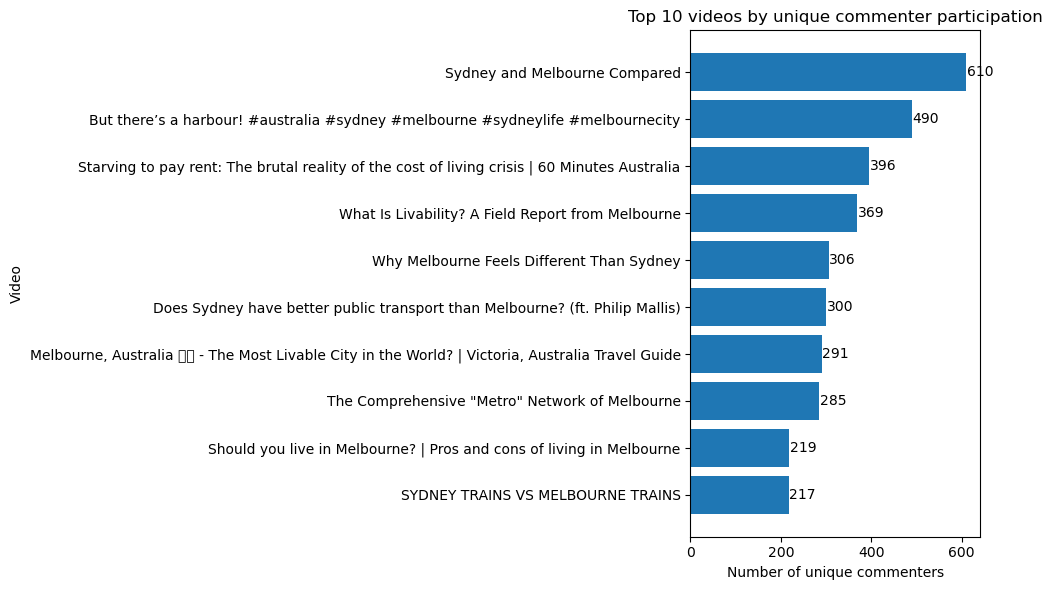

In [92]:
# Top 10 videos by unique commenter degree
plot_df = top_videos.head(10).copy()

plt.figure(figsize=(10, 6))
bars = plt.barh(plot_df["videoTitle"], plot_df["video_degree"])
plt.xlabel("Number of unique commenters")
plt.ylabel("Video")
plt.title("Top 10 videos by unique commenter participation")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f"{int(width)}", va="center")

plt.tight_layout()
plt.show()

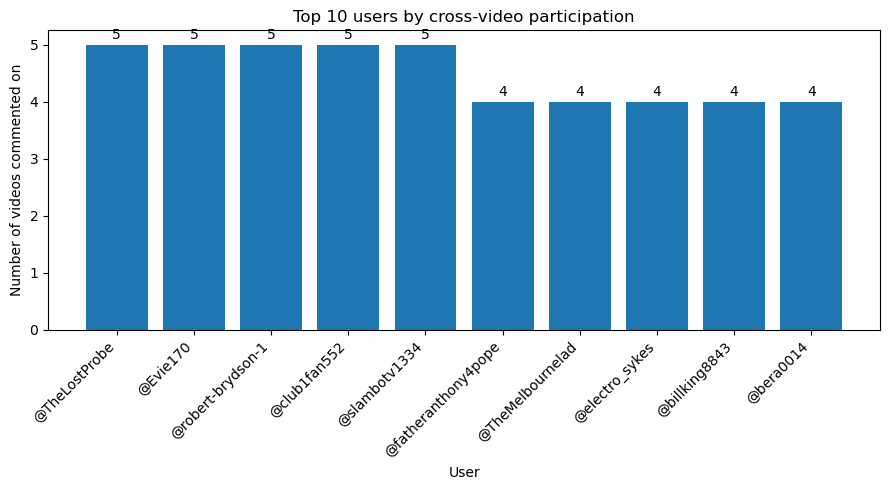

In [93]:
# Top 10 users by number of videos commented on
plot_df = top_users.head(10).copy()

plt.figure(figsize=(9, 5))
bars = plt.bar(plot_df["authorDisplayName"], plot_df["user_degree"])
plt.xlabel("User")
plt.ylabel("Number of videos commented on")
plt.title("Top 10 users by cross-video participation")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{int(height)}", ha="center")

plt.tight_layout()
plt.show()

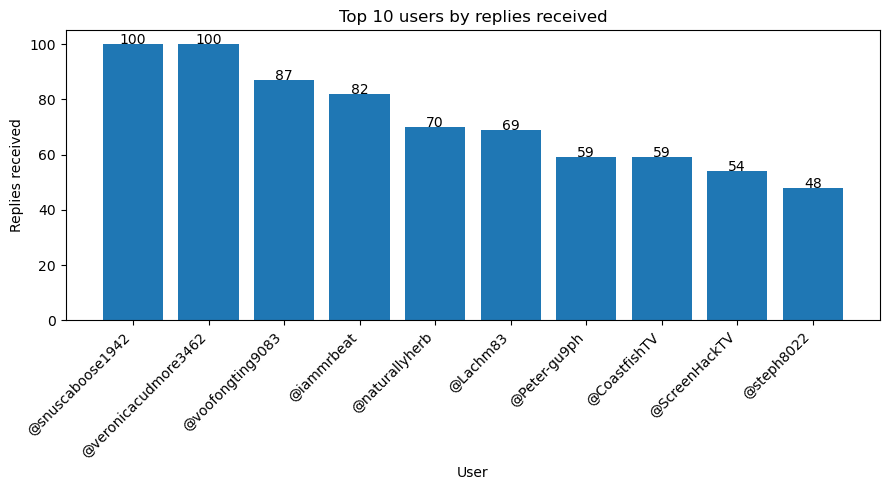

In [94]:
# Top 10 reply recipients
plot_df = top_reply_in.head(10).copy()

plt.figure(figsize=(9, 5))
bars = plt.bar(plot_df["authorDisplayName"], plot_df["weighted_in_degree"])
plt.xlabel("User")
plt.ylabel("Replies received")
plt.title("Top 10 users by replies received")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{int(height)}", ha="center")

plt.tight_layout()
plt.show()

## Save outputs

In [97]:
top_videos.to_csv(TOP_VIDEO_CENTRALITY_FILE, index=False, encoding="utf-8-sig")
top_user_projection.to_csv(TOP_USER_CENTRALITY_FILE, index=False, encoding="utf-8-sig")
top_reply_in.to_csv(TOP_REPLY_USERS_FILE, index=False, encoding="utf-8-sig")

network_summary = {}
network_summary.update(bipartite_summary)
network_summary.update(projected_summary)
network_summary.update(reply_summary)

with open(NETWORK_SUMMARY_FILE, "w", encoding="utf-8") as f:
    json.dump(network_summary, f, ensure_ascii=False, indent=2)

network_summary

{'total_nodes': 4298,
 'total_edges': 4582,
 'user_nodes': 4272,
 'video_nodes': 26,
 'density': 0.0004961960648035093,
 'connected_components': 4,
 'user_projection_nodes': 234,
 'user_projection_edges': 970,
 'user_projection_density': 0.03558196691243901,
 'user_projection_connected_components': 20,
 'reply_nodes': 2952,
 'reply_edges': 3718,
 'reply_density': 0.0004267994221792438,
 'reply_weakly_connected_components': 124}

## Preliminary network interpretation

This section helps turn the graph outputs into report-ready language.

In [98]:
print("Network analysis complete.\n")

print("Primary bipartite network summary:")
for k, v in bipartite_summary.items():
    print(f"- {k}: {v}")

print("\nProjected user-user network summary:")
for k, v in projected_summary.items():
    print(f"- {k}: {v}")

print("\nReply network summary:")
for k, v in reply_summary.items():
    print(f"- {k}: {v}")

print("\nTop 10 videos by unique commenter degree:")
print(top_videos.head(10).to_string(index=False))

print("\nTop 10 users in projected user network by degree centrality:")
print(top_user_projection.head(10).to_string(index=False))

print("\nTop 10 users by replies received:")
print(top_reply_in.head(10).to_string(index=False))

Network analysis complete.

Primary bipartite network summary:
- total_nodes: 4298
- total_edges: 4582
- user_nodes: 4272
- video_nodes: 26
- density: 0.0004961960648035093
- connected_components: 4

Projected user-user network summary:
- user_projection_nodes: 234
- user_projection_edges: 970
- user_projection_density: 0.03558196691243901
- user_projection_connected_components: 20

Reply network summary:
- reply_nodes: 2952
- reply_edges: 3718
- reply_density: 0.0004267994221792438
- reply_weakly_connected_components: 124

Top 10 videos by unique commenter degree:
    videoId  video_degree                                                                                       videoTitle
ea14oVK8XLw           610                                                                    Sydney and Melbourne Compared
MzgZV6CKDL4           490                  But there’s a harbour! #australia #sydney #melbourne #sydneylife #melbournecity
HRP1t-P0Ljw           396     Starving to pay rent: The bru

### Preliminary conclusion

The dataset supports multiple meaningful network constructions.

1. The **user–video bipartite network** captures participation structure and identifies which videos attract the broadest discussion.
2. The **projected user–user network** captures audience overlap by linking users who commented on the same videos.
3. The **directed reply network** captures more explicit interaction and can distinguish conversational patterns from simple co-participation.

The next notebook will focus on the text-analysis side of the project, especially topic modelling on the cleaned comment subset.